# Teste — treinar o modelo sem novembro

**Pergunta:** a Black November é fora da curva (3 a 4× o volume normal). Se o modelo **não treinar com novembro**, a previsão dos meses seguintes melhora?

**Como testamos:** mesma base, mesmas features e mesma validação faseada do `modelo_machine_learning_categorias.ipynb` (14 dias à frente, 7 rodadas de 01/04 a 30/06, parâmetros padrão). A única diferença é que, em cada rodada, as linhas de **novembro saem do treino**. O teste (abril a junho) é o mesmo nos dois casos, então a comparação é direta.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ID = "gms-prod-01"
BQ_LOCATION = "us-east4"
TABLE_ID = "gms-prod-01.projeto_gb.fact_vendas"
STG_TABLE_ID = "gms-prod-01.projeto_gb.stg_fact_vendas"

START_DATE = "2025-11-01"
END_DATE = "2026-06-30"

DATE_FILTER = f"DATE(dt_hr_venda) BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'"

# Validação faseada: o teste começa depois de 5 meses de treino
INICIO_TESTE = "2026-04-01"

COR_REAL = "#333333"
CORES_MODELO = {
    "naive_sazonal": "#9e9e9e",
    "mm7": "#bdbdbd",
    "mm28": "#757575",
    "regressao_linear": "#1f4e79",
    "lightgbm": "#6a994e",
    "xgboost": "#d17a22",
    "vencedor_ajustado": "#a23b72",
}

## Consumo BigQuery

Mesmas funções do notebook do modelo: dry-run antes de cada consulta e SQL lido da pasta `sql/`.

In [2]:
from gb_ml.io import ConsultasBQ

# Lê sql/<arquivo>, preenche {TABLE_ID}, {DATE_FILTER} etc. e roda no BigQuery (com dry-run antes)
bq = ConsultasBQ(
    project_id=PROJECT_ID,
    location=BQ_LOCATION,
    parametros={
        "TABLE_ID": TABLE_ID,
        "STG_TABLE_ID": STG_TABLE_ID,
        "DATE_FILTER": DATE_FILTER,
        "START_DATE": START_DATE,
        "END_DATE": END_DATE,
    },
)
run_bq, carregar_sql = bq.rodar, bq.carregar

# 1. Base e features

Mesma query de modelagem (`42_sql_base_modelagem.sql`, com as correções da análise exploratória) e mesmas features.

In [3]:
from gb_ml.features import montar_features

base = run_bq(carregar_sql("42_sql_base_modelagem.sql"), "base de modelagem: dia x canal x categoria")
base["data"] = pd.to_datetime(base["data"])
base["qt_material"] = base["qt_material"].astype(float)
df = montar_features(base)

em_novembro = df["data"].dt.month == 11
print(f"{len(df):,} linhas | novembro: {em_novembro.sum():,} linhas ({em_novembro.mean():.0%}) "
      f"e {df.loc[em_novembro, 'qt_material'].sum() / df['qt_material'].sum():.0%} do volume")

[BigQuery] base de modelagem: dia x canal x categoria | estimativa processada: 5.87 MB


4,356 linhas | novembro: 540 linhas (12%) e 36% do volume


# 2. Backtest com e sem novembro no treino

O filtro é aplicado **dentro de cada rodada**, só no treino. Sem novembro, a coluna `black_november` fica sempre zero no treino e deixa de ter efeito.

In [4]:
from gb_ml.model import (
    baseline, erro_por_rodada, gerar_folds, lightgbm, linear, resumo_backtest, rodar_backtest, xgboost,
)

folds_teste = gerar_folds(INICIO_TESTE, END_DATE)


def sem_novembro(ajustar_prever):
    """Mesmo modelo, treinando sem as linhas de novembro."""
    return lambda treino, teste: ajustar_prever(treino[treino["data"].dt.month != 11], teste)


MODELOS = {
    "lightgbm": lightgbm(alvo="poisson", usar_lags=False),
    "xgboost": xgboost(alvo="poisson", usar_lags=False),
    "regressao_linear": linear(alvo="log", interacao=False),
}
previsoes = {}
for nome, modelo in MODELOS.items():
    previsoes[(nome, "com novembro")] = rodar_backtest(df, folds_teste, modelo)
    previsoes[(nome, "sem novembro")] = rodar_backtest(df, folds_teste, sem_novembro(modelo))
previsoes[("mm7", "baseline")] = rodar_backtest(df, folds_teste, baseline("mm7"))

resultado = pd.DataFrame({chave: resumo_backtest(p) for chave, p in previsoes.items()}).T
resultado.index.names = ["modelo", "treino"]
display(resultado[["wape_dia", "vies_dia", "wape_serie"]].map(lambda v: f"{v:.1%}"))

wape_dia vies_dia wape_serie
modelo           treino                                   
lightgbm         com novembro    25.5%    -7.4%      37.9%
                 sem novembro    26.8%    -8.8%      38.8%
xgboost          com novembro    26.4%    -9.3%      38.3%
                 sem novembro    29.4%   -11.8%      41.0%
regressao_linear com novembro    27.2%   -15.9%      37.7%
                 sem novembro    27.9%   -16.8%      38.1%
mm7              baseline        35.8%    -0.3%      51.5%

### Erro por rodada

,lightgbm · com novembro,lightgbm · sem novembro,mm7 · baseline
rodada,,,
1,17.7%,20.4%,21.4%
2,14.1%,16.4%,12.3%
3,43.0%,44.3%,35.8%
4,26.6%,27.3%,32.0%
5,25.6%,25.4%,87.9%
6,26.0%,25.9%,31.0%
7,12.7%,14.7%,39.1%


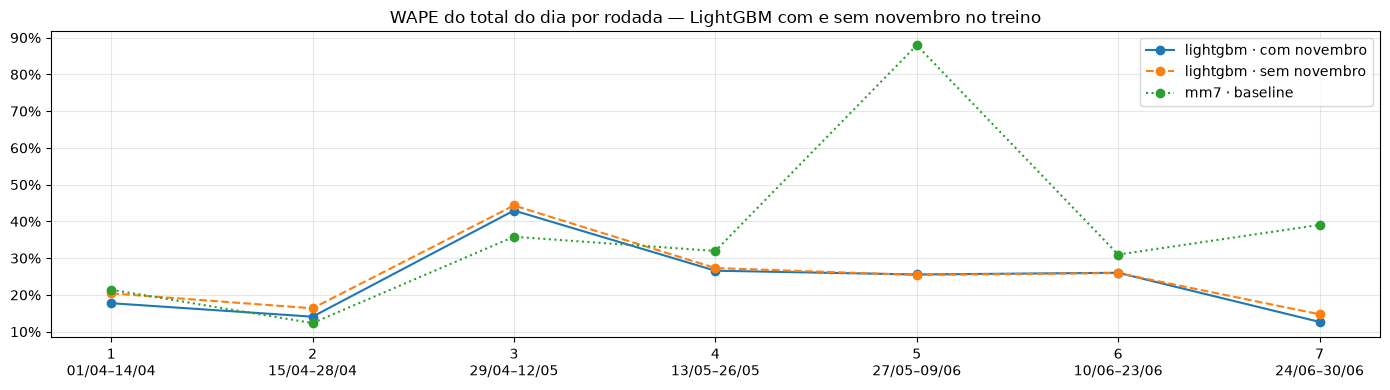

In [5]:
por_rodada = pd.DataFrame({
    f"{modelo} · {treino}": erro_por_rodada(p).set_index("rodada")["wape"]
    for (modelo, treino), p in previsoes.items() if modelo in ("lightgbm", "mm7")
})
display(por_rodada.map(lambda v: f"{v:.1%}"))

rotulos = [f"{r}\n{i:%d/%m}–{f:%d/%m}" for r, i, f in folds_teste[["rodada", "inicio", "fim"]].itertuples(index=False)]
fig, ax = plt.subplots(figsize=(14, 4))
for coluna, estilo in zip(por_rodada.columns, ["-", "--", ":"]):
    ax.plot(por_rodada.index, por_rodada[coluna], marker="o", ls=estilo, label=coluna)
ax.set_xticks(folds_teste["rodada"], rotulos)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("WAPE do total do dia por rodada — LightGBM com e sem novembro no treino")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Diagnóstico

- **Tirar novembro do treino piora os três modelos** no total do dia: LightGBM de 25,5% para 26,8%, XGBoost de 26,4% para 29,4% e regressão linear de 27,2% para 27,9%. O viés também fica mais negativo (o modelo subestima mais).
- **Por quê:** novembro é o único período com **desconto muito alto**. É com ele que o modelo aprende quanto o volume responde a um salto de desconto. Sem novembro, a resposta a promoções fica subestimada; isso aparece na última rodada (24 a 30/06, desconto de fim de mês), que piora de 12,7% para 14,7% no LightGBM.
- **A Black November já é tratada como feature** (`black_november`), então o modelo não confunde o nível de novembro com o dos outros meses: ele separa o efeito em vez de ser distorcido por ele.

**Decisão:** manter novembro no treino. Ser fora da curva é um motivo para **marcar** o período com uma feature, não para **remover** os dados.